### Objectives
- graphs to represent agent workflows
- looping and conditional 
- LangGraph application
- visualize LangGraph workflow execution and state progression

### Sample application
- a counter starts at one and increments its values. Generate random letters. prints the result until it reaches 13.

### State in LangGraph
- in the counter example
    - state is random letter and the integer
    - state is defined with `TypedDict`
    - Note: Struct like TypedDict only contain one value per key at a time


In [6]:
# Define state structure with TypeDict

import random
import string
from typing import TypedDict

from langgraph.graph import StateGraph, END

class ChainState(TypedDict):
    n: int
    letter: str

initial_state = ChainState(n=1, letter="a")

print("Initial state:", initial_state)

Initial state: {'n': 1, 'letter': 'a'}


### Function-based nodes
- node links to a fucntion that process state
- `return {**state, "n":state["n"] + 1, "letter":random_letter}` the `**state` unpack the original dictionary

In [14]:
import random
import string

def add(state: ChainState) -> ChainState:
    random_letter = random.choice(string.ascii_lowercase)
    return {**state, "n":state["n"] + 1, "letter":random_letter}



- Nodes are designed to modify data

In [15]:
def print_out(state: ChainState) -> ChainState:
    print(f"Current n: {state['n']}, Letter: {state['letter']}")
    return state

- create a StateGraph Object initialized with the ChainState class
- The workflow consist of 
    - Nodes: logic to process state
    - Edges: trasistion between nodes based on conditions
    - END state: the object says the process flow is complete

- `add_node()` method takes 2 arguments
    - the `node_name` and the `function`
    - node name may differ from function name

In [ ]:
from langgraph.graph import StateGraph, END

workflow = StateGraph(ChainState)

# incorporate the add function using add_node method
workflow.add_node("add", add)
workflow.add_node("print", print_out)

# add an edge from add to print
workflow.add_edge("add", "print")

# special nodes check the conditions
def stop_condition(state: ChainState) -> bool:
    return state["n"] >= 13

# can insert conditional edge from prit to end node
workflow.add_conditional_edges("print",  # source node
                               stop_condition, # logic function
                  {                            # path map                   True: END, 
                      False: "add",
                }
)

### Alternate routing approch
- Desing the condition node to return name of the next node

```python
def stop_conditon(state: ChainState) -> bool:
    if state["n"] >= 13:
        return END
    return "add"

workflow.add_conditional_edges("print", should_continue)
```

- Set entry point
- indicate the fist processing node
- after the entry point set, call compile to compile the graph

In [19]:
workflow.set_entry_point("add")

app = workflow.compile()

### complete workflow
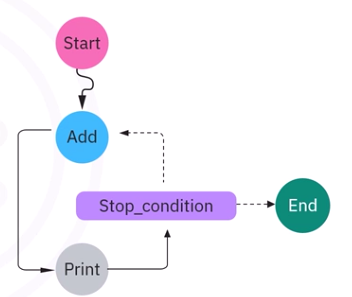

In [20]:
result = app.invoke({"n":1, "letter": ""})

Current n: 2, Letter: e
Current n: 3, Letter: g
Current n: 4, Letter: s
Current n: 5, Letter: v
Current n: 6, Letter: v
Current n: 7, Letter: r
Current n: 8, Letter: z
Current n: 9, Letter: a
Current n: 10, Letter: o
Current n: 11, Letter: y
Current n: 12, Letter: x
Current n: 13, Letter: z
